# Cluster Analysis – Heart Disease Dataset
*Cluster analysis for Cardio - Risk Prediction project*  

---

## Table of Contents


<a id='imports'></a>
## Reproducibility & Imports  
---

In [48]:
# Reproducibility
import os, sys, numpy as np
import joblib, pandas as pd

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from plotly.io import show
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from scripts.dim_red.plots import plot_3d
from matplotlib import pyplot as plt
from scripts.clustering.utils import plot_smd_heatmap, plot_smd_stacked_bars, top_union_smd_table, compute_smds, plot_clusters_target_3d, cluster_profile, rank_leaderboard, build_global_leaderboard, append_result, show_scores, select_k_kmeans, select_k_agglomerative, gridsearch_dbscan, k_distance_plot, gridsearch_kmeans_params, gridsearch_agglomerative_params

SEED = 42
TARGET_COL = "DEATH_EVENT"
OUTPUT_DIR = "../outputs/clustering"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
df_pca = joblib.load('../outputs/dim_red/df_pca.pkl')
df_tsne = joblib.load('../outputs/dim_red/df_tsne.pkl')
df_umap = joblib.load('../outputs/dim_red/df_umap.pkl')
df_mix = joblib.load('../outputs/dim_red/df_mix.pkl')
df_preprocessed = joblib.load('../outputs/eda/df_preprocessed_balanced.pkl')

In [3]:
X_pca  = df_pca.iloc[:, :-1]
X_tsne = df_tsne.iloc[:, :-1]
X_umap = df_umap.iloc[:, :-1]
X_mix = df_mix.iloc[:, :-1]
X_pre  = df_preprocessed.iloc[:, :-1]
y = df_preprocessed.iloc[:, -1]

cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X_pre = X_pre.drop(columns=cols_to_drop)

datasets = {
    "pca": X_pca,
    "tsne": X_tsne,
    "umap": X_umap,
    "mix": X_mix,
}

rows: list[dict] = []

## DBSCAN

In [4]:
dbscan_params = {
    "pca":  {"eps": 0.2, "min_samples": 5},
    "tsne": {"eps": 1.2, "min_samples": 3},
    "umap": {"eps": 0.8, "min_samples": 10},
    "mix":  {"eps": 0.8, "min_samples": 3},
}

for name, X in datasets.items():
    p = dbscan_params[name]
    
    db = DBSCAN(eps=p["eps"], min_samples=p["min_samples"])
    labels = db.fit_predict(X)

    scores = show_scores(f"DBSCAN on {name}", X, labels, y)
    append_result(rows, name, "dbscan", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'DBSCAN on {name}', target_name="cluster")
    show(fig)


[DBSCAN on pca] -> clusters=2, noise=4.2%, sil=0.21317452249465685, CH=8.68334275600144, DB=3.447573905424029, ARI=0.05214570347001016, NMI=0.048469451828312284, V=0.04846945182831228


[DBSCAN on tsne] -> clusters=25, noise=7.5%, sil=0.12047891318798065, CH=46.4655876159668, DB=1.6171936861523126, ARI=0.043519243485287455, NMI=0.18252636941385084, V=0.18252636941385084


[DBSCAN on umap] -> clusters=5, noise=0.6%, sil=0.4236181676387787, CH=219.84384155273438, DB=0.9559692510718913, ARI=0.15524995993479257, NMI=0.17600014966472874, V=0.17600014966472874


[DBSCAN on mix] -> clusters=3, noise=0.0%, sil=0.3987852531047934, CH=429.52204632858405, DB=0.587011766242988, ARI=0.04493476072176693, NMI=0.15622307611350766, V=0.15622307611350766


## KMeans

In [5]:
kmeans_params = {
    "pca":  {"k": 4, "n_init": 20},
    "tsne": {"k": 5, "n_init": 10},
    "umap": {"k": 5, "n_init": 10},
    "mix":  {"k": 2, "n_init": 10},
}

for name, X in datasets.items():
    p = kmeans_params[name]
    
    km = KMeans(n_clusters=p["k"], n_init=p["n_init"], random_state=SEED)
    labels = km.fit_predict(X)

    scores = show_scores(f"KMeans on {name}", X, labels, y)
    append_result(rows, name, "kmeans", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'KMeans on {name}', target_name="cluster")
    show(fig)

[KMeans on pca] -> clusters=4, noise=0.0%, sil=0.3176439730002902, CH=150.30032628161473, DB=1.0678346669027357, ARI=0.12714911317434913, NMI=0.15084770183414495, V=0.15084770183414498


[KMeans on tsne] -> clusters=5, noise=0.0%, sil=0.39721426367759705, CH=227.57489013671875, DB=0.8871370582053826, ARI=0.16105180324185542, NMI=0.21694863690232513, V=0.21694863690232516


[KMeans on umap] -> clusters=5, noise=0.0%, sil=0.5001122355461121, CH=325.3822937011719, DB=0.7193349161030735, ARI=0.18879531524692741, NMI=0.18877574870669203, V=0.18877574870669203


[KMeans on mix] -> clusters=2, noise=0.0%, sil=0.5786823175821805, CH=720.055654798926, DB=0.5732303091627815, ARI=0.15706961320453955, NMI=0.2105112732965428, V=0.21051127329654276


## Aglomerative

In [6]:
agglo_params = {
    "pca":  {"k": 7, "linkage": "ward",     "metric": "euclidean"},
    "tsne": {"k": 5, "linkage": "complete", "metric": "euclidean"},
    "umap": {"k": 7, "linkage": "average",  "metric": "manhattan"},
    "mix":  {"k": 2, "linkage": "ward",     "metric": "euclidean"},
}

for name, X in datasets.items():
    p = agglo_params[name]
    
    agg = AgglomerativeClustering(n_clusters=p["k"], linkage=p["linkage"], metric=p["metric"])
    labels = agg.fit_predict(X)

    scores = show_scores(f"Agglomerative on {name}", X, labels, y)
    append_result(rows, name, "agglomerative", labels, scores["internal"], scores["external"], params=p)

    fig = plot_3d(X3d=X, y=labels, algorithm=f'Agglomerative on {name}', target_name="cluster")
    show(fig)

[Agglomerative on pca] -> clusters=7, noise=0.0%, sil=0.2809326919123936, CH=115.42192839568682, DB=1.0806819337161506, ARI=0.18201909845392264, NMI=0.2641136284896929, V=0.2641136284896929


[Agglomerative on tsne] -> clusters=5, noise=0.0%, sil=0.3733208477497101, CH=204.91714477539062, DB=0.8815848806632423, ARI=0.15656092734531793, NMI=0.20367834014990624, V=0.20367834014990624


[Agglomerative on umap] -> clusters=7, noise=0.0%, sil=0.4718312919139862, CH=335.157958984375, DB=0.6372203903983433, ARI=0.18697689302237325, NMI=0.2450580986664114, V=0.24505809866641134


[Agglomerative on mix] -> clusters=2, noise=0.0%, sil=0.5949226817019988, CH=631.5637530451563, DB=0.46358778231756764, ARI=0.018841639529996304, NMI=0.1655762113155323, V=0.1655762113155323


## Best params finder

[pca] DBSCAN best: {'eps': 0.2, 'min_samples': 5} {'silhouette': 0.21317452249465685, 'calinski_harabasz': 8.68334275600144, 'davies_bouldin': 3.447573905424029, 'n_clusters': 2, 'noise_%': 4.220779220779221}
[tsne] DBSCAN best: {'eps': 1.2, 'min_samples': 3} {'silhouette': 0.12047891318798065, 'calinski_harabasz': 46.4655876159668, 'davies_bouldin': 1.6171936861523126, 'n_clusters': 25, 'noise_%': 7.467532467532467}
[umap] DBSCAN best: {'eps': 0.8, 'min_samples': 10} {'silhouette': 0.4236181676387787, 'calinski_harabasz': 219.84384155273438, 'davies_bouldin': 0.9559692510718913, 'n_clusters': 5, 'noise_%': 0.6493506493506493}
[mix] DBSCAN best: {'eps': 0.8, 'min_samples': 3} {'silhouette': 0.3987852531047934, 'calinski_harabasz': 429.52204632858405, 'davies_bouldin': 0.587011766242988, 'n_clusters': 3, 'noise_%': 0.0}


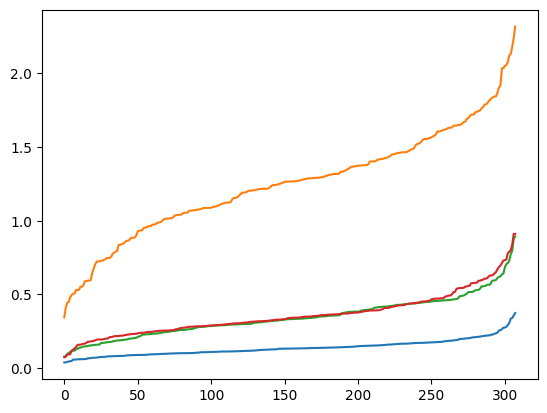

In [7]:
dbscan_best = {}
for name, X in datasets.items():
    kd = k_distance_plot(X=X)
    plt.plot(kd)
    
    db_best = gridsearch_dbscan(X=X)
    dbscan_best[name] = db_best
    print(f"[{name}] DBSCAN best:", db_best["params"], db_best["metrics"])


In [8]:
kmeans_best = {}
agglom_best = {}

for emb, X in datasets.items():
    kmeans_best[emb]  = gridsearch_kmeans_params(X, ks=range(2, 6), n_inits=(10, 20))
    agglom_best[emb]  = gridsearch_agglomerative_params(X, ks=range(2, 6), linkages=("ward","complete","average"), metrics=("euclidean","manhattan","cosine"))
    print(f"[{emb}] KMeans best:", kmeans_best[emb]["params"])
    print(f"[{emb}] Agglomerative best:", agglom_best[emb]["params"])

[pca] KMeans best: {'k': 4, 'n_init': 20}
[pca] Agglomerative best: {'k': 4, 'linkage': 'ward', 'metric': 'euclidean'}
[tsne] KMeans best: {'k': 5, 'n_init': 10}
[tsne] Agglomerative best: {'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}
[umap] KMeans best: {'k': 5, 'n_init': 10}
[umap] Agglomerative best: {'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}
[mix] KMeans best: {'k': 2, 'n_init': 10}
[mix] Agglomerative best: {'k': 2, 'linkage': 'ward', 'metric': 'euclidean'}


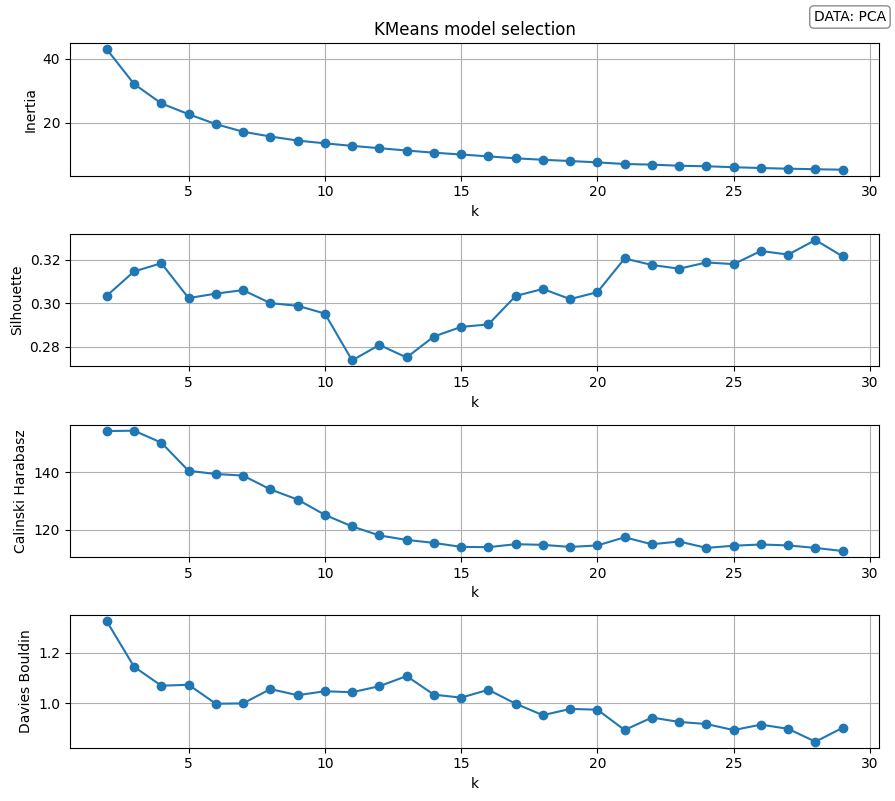

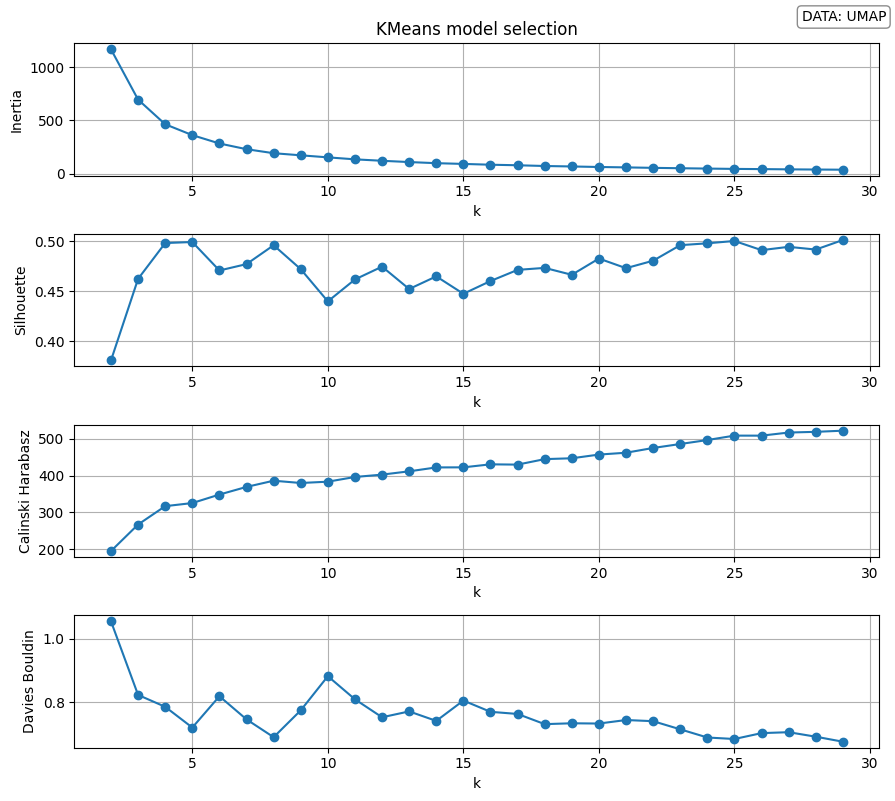

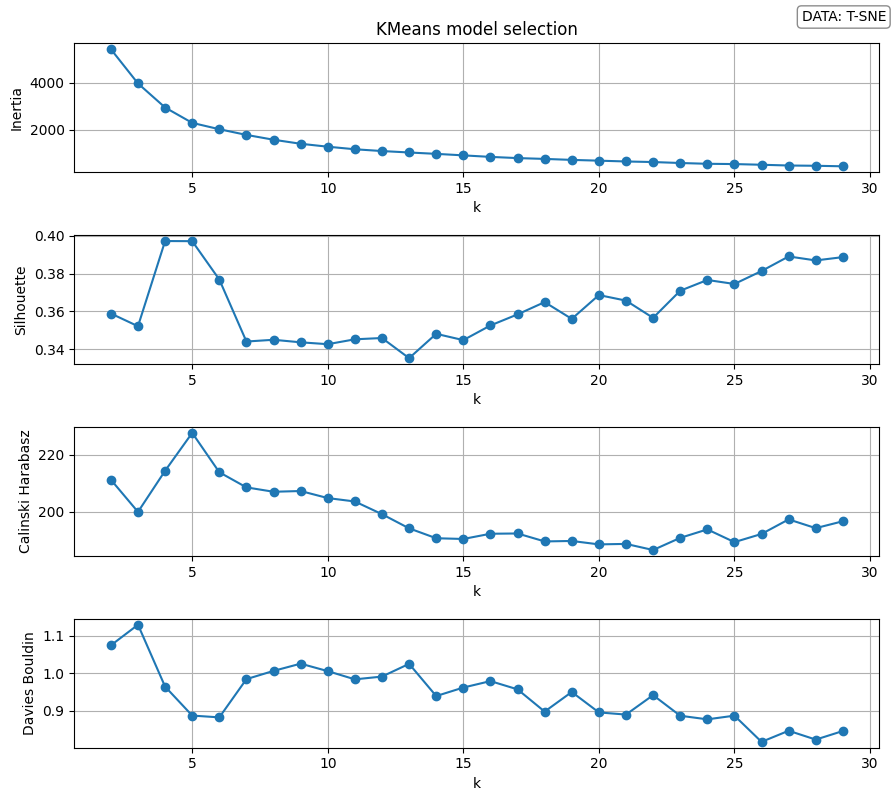

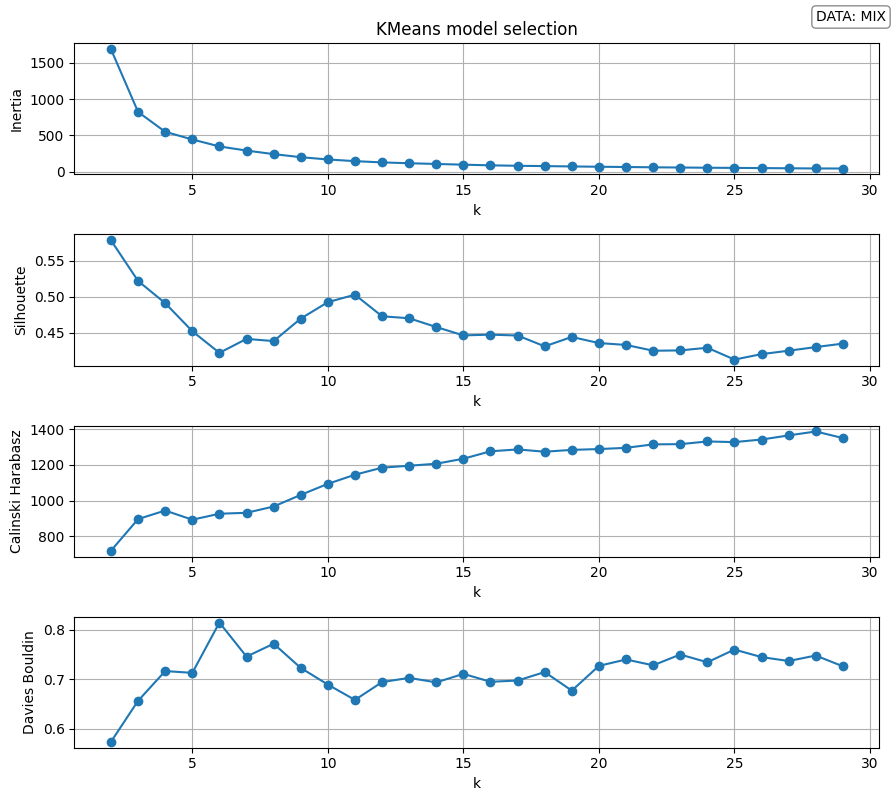


KMeans on PCA
{'inertia': 29, 'silhouette': 28, 'calinski_harabasz': 3, 'davies_bouldin': 28}

KMeans on UMAP
{'inertia': 29, 'silhouette': 29, 'calinski_harabasz': 29, 'davies_bouldin': 29}

KMeans on T-SNE
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 5, 'davies_bouldin': 26}

KMeans on MIX
{'inertia': 29, 'silhouette': 2, 'calinski_harabasz': 28, 'davies_bouldin': 2}


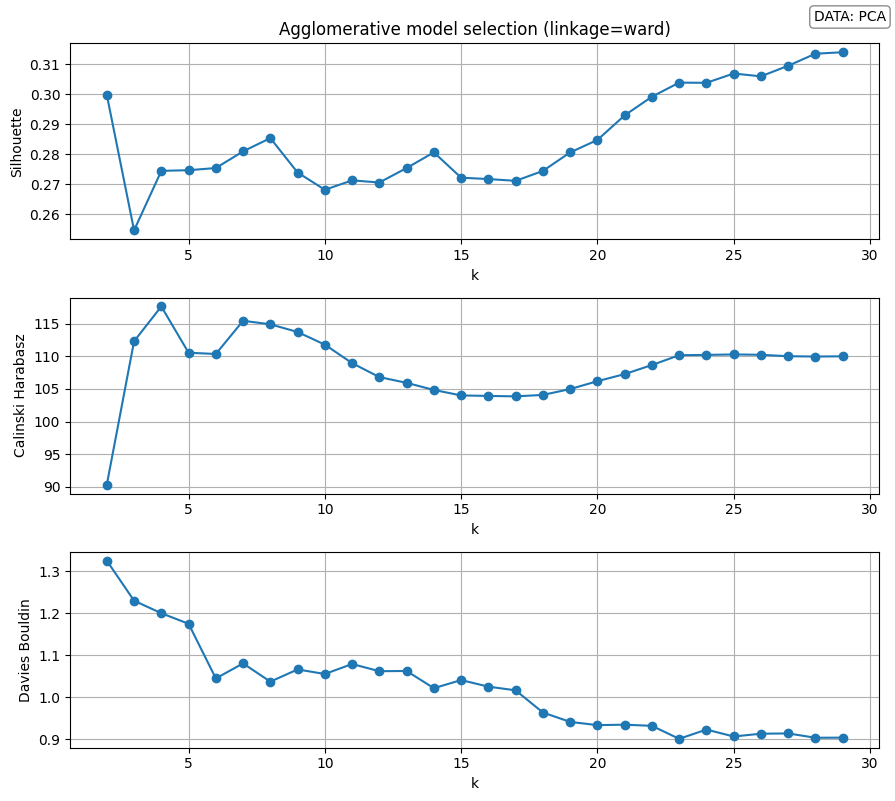

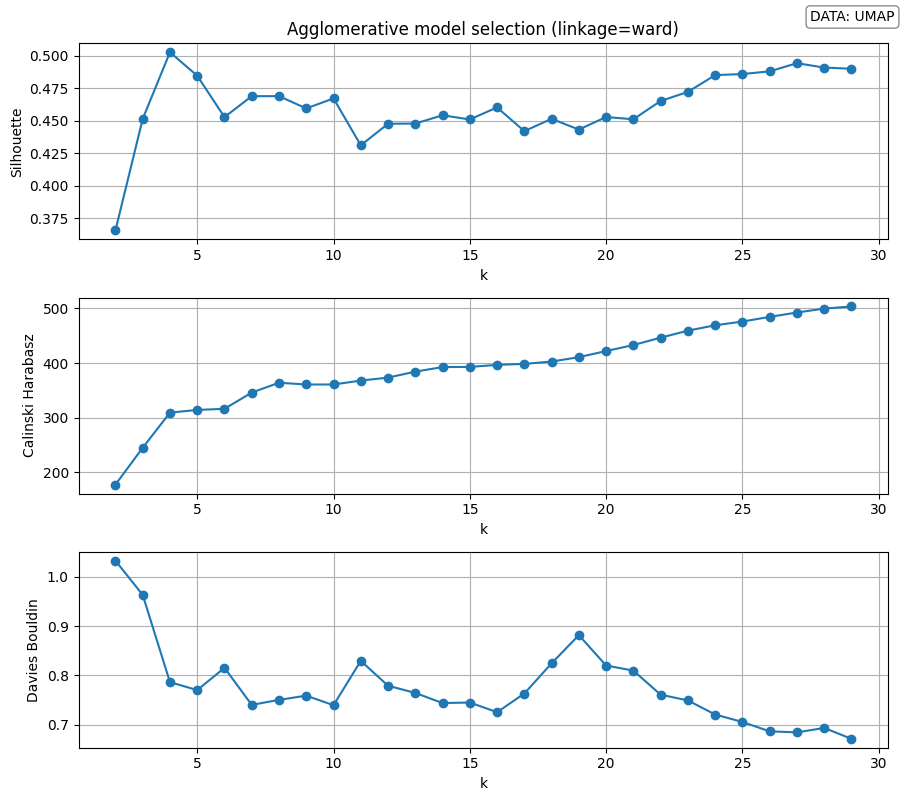

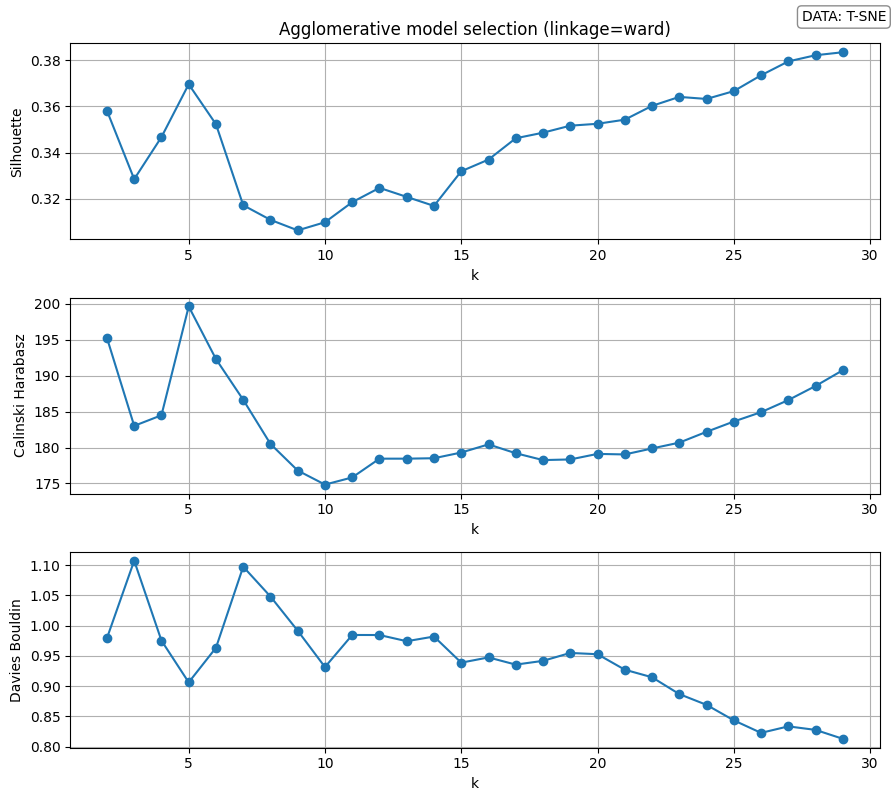

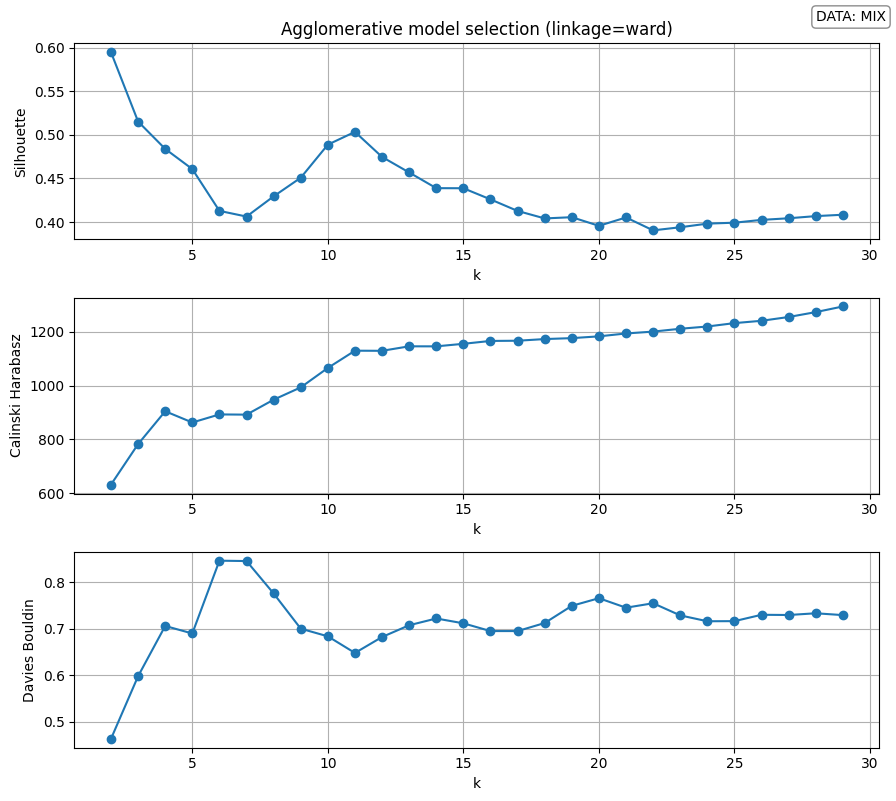


Agglomerative on PCA
{'silhouette': 29, 'calinski_harabasz': 4, 'davies_bouldin': 23}

Agglomerative on UMAP
{'silhouette': 4, 'calinski_harabasz': 29, 'davies_bouldin': 29}

Agglomerative on T-SNE
{'silhouette': 29, 'calinski_harabasz': 5, 'davies_bouldin': 29}

Agglomerative on MIX
{'silhouette': 2, 'calinski_harabasz': 29, 'davies_bouldin': 2}


In [9]:
# KMEANS
kmeans_results = {
    'pca':  select_k_kmeans(X_pca,  k_range=range(2, 30), n_init=50, data_name="PCA"),
    'umap': select_k_kmeans(X_umap, k_range=range(2, 30), n_init=50, data_name="UMAP"),
    't-SNE':select_k_kmeans(X_tsne, k_range=range(2, 30), n_init=50, data_name="t-SNE"),
    'MIX':  select_k_kmeans(X_mix,  k_range=range(2, 30), n_init=50, data_name="MIX"),
}

for name, res in kmeans_results.items():
    print(f"\nKMeans on {name.upper()}")
    print(res.best_by_metric)
    
# AGGLOMERATIVE
agg_results = {
    'pca':  select_k_agglomerative(X_pca,  k_range=range(2, 30), data_name="PCA"),
    'umap': select_k_agglomerative(X_umap, k_range=range(2, 30), data_name="UMAP"),
    't-SNE':select_k_agglomerative(X_tsne, k_range=range(2, 30), data_name="t-SNE"),
    'MIX':  select_k_agglomerative(X_mix,  k_range=range(2, 30), data_name="MIX"),
}

for name, res in agg_results.items():
    print(f"\nAgglomerative on {name.upper()}")
    print(res.best_by_metric)

### Best result overall

In [17]:
board = build_global_leaderboard(datasets)
ordered = rank_leaderboard(board)
df_leaderboard = pd.DataFrame(rows)

rows = []
for i, r in enumerate(ordered, 1):
    m = r["metrics"]
    rows.append({
        "Rank": i,
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4)
    })

display(df_leaderboard.style
    .background_gradient(subset=["Silhouette"], cmap="Greens")
    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")
    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})
)

,Rank,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,1,MIX,AGGLOMERATIVE,"{'k': 2, 'linkage': 'ward', 'metric': 'euclidean'}",2,0.5949,631.56,0.4636
1,2,MIX,KMEANS,"{'k': 2, 'n_init': 10}",2,0.5787,720.06,0.5732
2,3,UMAP,KMEANS,"{'k': 5, 'n_init': 10}",5,0.5001,325.38,0.7193
3,4,UMAP,AGGLOMERATIVE,"{'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}",5,0.4860,315.01,0.7395
4,5,UMAP,DBSCAN,"{'eps': 0.8, 'min_samples': 10}",5,0.4236,219.84,0.9560
5,6,MIX,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.3988,429.52,0.5870
6,7,TSNE,KMEANS,"{'k': 5, 'n_init': 10}",5,0.3972,227.57,0.8871
7,8,TSNE,AGGLOMERATIVE,"{'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}",5,0.3733,204.92,0.8816
8,9,PCA,KMEANS,"{'k': 4, 'n_init': 20}",4,0.3176,150.30,1.0678
9,10,PCA,AGGLOMERATIVE,"{'k': 4, 'linkage': 'ward', 'metric': 'euclidean'}",4,0.2744,117.61,1.1999


### Cluster profile of TOP-5

In [27]:
X_orig = X_pre.copy()   # compute profile on original features
interpretation = {}

for i, r in enumerate(ordered[:5], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]
    
    prof, overall = cluster_profile(X_orig, labels)
    interpretation[(emb, algo, i)] = {"profile": prof, "overall": overall, "params": params, "metrics": m}

    print(f"\n=== {i}. {emb} – {algo} ===  \nparams={params}")
    display(prof.style.format("{:.3f}"))


=== 1. MIX – AGGLOMERATIVE ===  
params={'k': 2, 'linkage': 'ward', 'metric': 'euclidean'}



=== 2. MIX – KMEANS ===  
params={'k': 2, 'n_init': 10}



=== 3. UMAP – KMEANS ===  
params={'k': 5, 'n_init': 10}



=== 4. UMAP – AGGLOMERATIVE ===  
params={'k': 5, 'linkage': 'complete', 'metric': 'euclidean'}



=== 5. UMAP – DBSCAN ===  
params={'eps': 0.8, 'min_samples': 10}


### SMD tables for the top-3 entries

In [41]:
topK = 3
top_smd_tables = {}

for i, r in enumerate(ordered[:topK], 1):
    smd_df = compute_smds(X_orig, r["labels"])
    top_smd_tables[(i, r["emb"].upper(), r["algo"].upper())] = smd_df

for rank in range(1, topK+1):
    entry = ordered[rank-1]
    key = (rank, entry['emb'].upper(), entry['algo'].upper())
    smd_df = top_smd_tables[key]
    tbl = top_union_smd_table(smd_df, top_n=8, feature_order="max")
    display(tbl.style.format("{:.3f}").set_caption(f"|SMD| cluster — [{rank}] {key[1]} – {key[2]}"))


,Cluster 0,Cluster 1
Feature,,
time,0.482,1.244
serum_creatinine,0.160,0.414
age,0.114,0.293
serum_sodium,0.062,0.161
ejection_fraction,0.021,0.055


,Cluster 0,Cluster 1
Feature,,
time,1.005,0.705
serum_creatinine,0.345,0.242
age,0.206,0.145
serum_sodium,0.086,0.061
ejection_fraction,0.003,0.002


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Feature,,,,,
serum_creatinine,0.321,0.185,1.528,0.231,0.709
ejection_fraction,1.293,1.035,0.307,0.018,0.128
time,0.498,1.103,0.694,1.191,0.394
age,0.787,0.109,0.242,0.221,0.489
serum_sodium,0.303,0.572,0.708,0.109,0.049


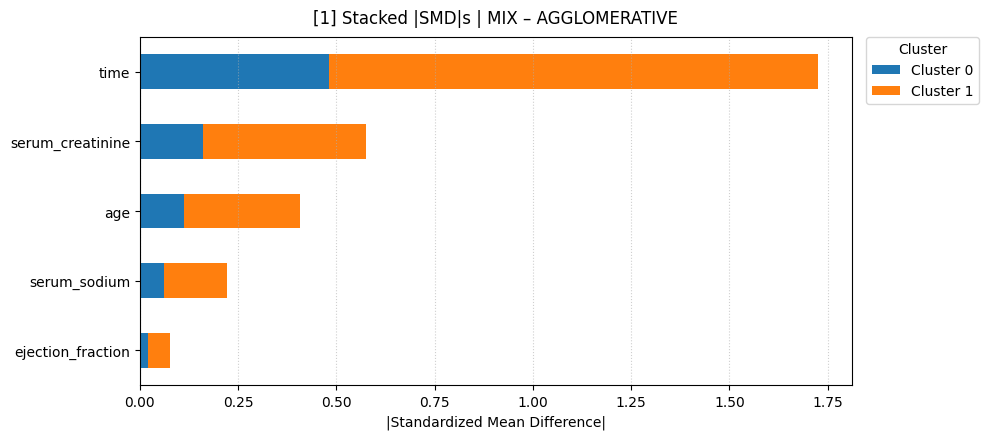

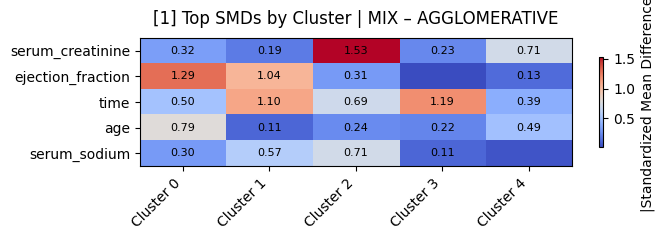

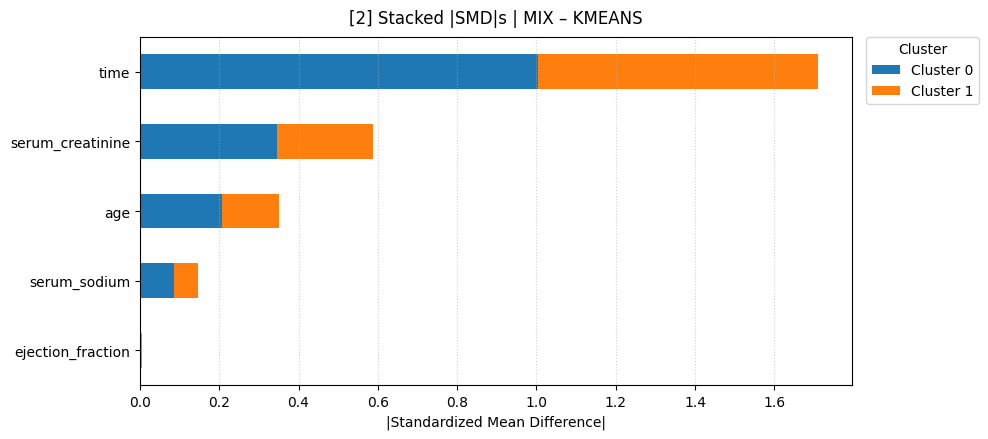

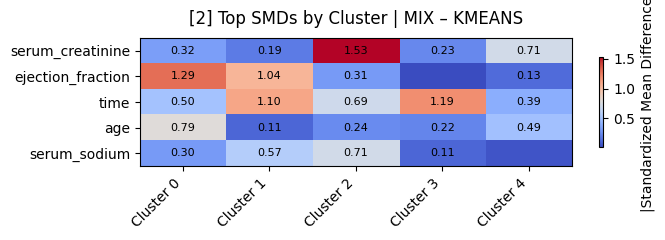

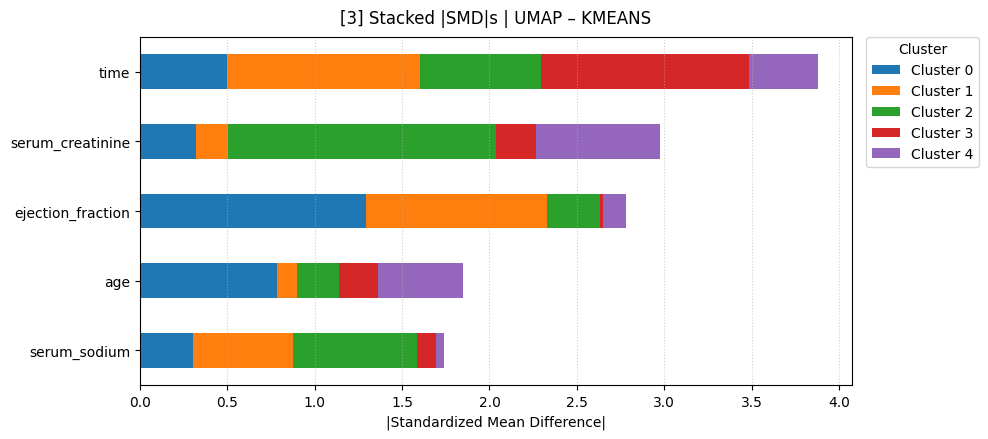

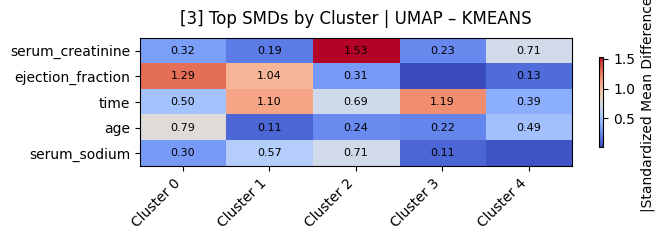

In [47]:
for rank in range(1, topK + 1):
    entry = ordered[rank - 1]
    key = (rank, entry['emb'].upper(), entry['algo'].upper())

    plot_smd_stacked_bars(top_smd_tables[key], title=f"[{rank}] Stacked |SMD|s | {key[1]} – {key[2]}",)
    plot_smd_heatmap(smd_df, title=f"[{rank}] Top SMDs by Cluster | {key[1]} – {key[2]}")


In [52]:
for rank in range(1, topK + 1):
    entry = ordered[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"].lower()
    labels = entry["labels"]

    title = f"[{rank}] {emb.upper()} – {algo}  params={params} | Clusters vs DEATH_EVENT"
    plot_clusters_target_3d(datasets[emb], labels, y, title=title)


In [24]:
rank = 1
entry = ordered[rank - 1]

rank_key = (rank, entry["emb"].upper(), entry["algo"].upper())

algo   = entry["algo"].upper()
emb    = entry["emb"].lower()
params = entry["params"]
labels = entry["labels"]

# --- Select corresponding embedding matrix ---
X = datasets[emb].values if hasattr(X, "values") else np.asarray(X)

# --- Prepare title and target ---
yt = y.values if hasattr(y, "values") else np.asarray(y)
title = f"[{rank}] {emb.upper()} – {algo}  params={params} | Clusters vs DEATH_EVENT"

# --- Plot ---
plot_clusters_target_3d(X, labels, yt, title)


1 wykres: cluster 1 to sa,o zdrowi
3 wykres: + to w zasadzie sami zdrowi

## Preprocessed dataset